**MID_EXAMS**

**Artificial Intelligence**

*Name: Alisha Khan*

*Batch-II*

**Section: A**

**Data Cleaning and Preprocessing**

1) Extract data from a csv file using python libraries like pandas. clean and preprocess the data by handling missing values, outliers, and data type conversion. Perform EDA to understand the data distribution and relationship.

In [8]:
# Load data
import pandas as pd
import numpy as np
df = pd.read_csv('/content/yFinData.csv')

In [3]:
# data extracting
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,4/28/2023,33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,4/29/2023,33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,4/30/2023,33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,5/1/2023,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,5/2/2023,33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   object 
 1   Open       1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Close      1258 non-null   float64
 5   Adj Close  1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,29595.823045,29776.945739,29402.432226,29599.361677,29599.361677,3.450636e+08
std,4006.078299,4009.007573,4004.949066,4007.468822,4007.468822,1.069142e+08
min,19028.360000,19121.010000,18213.650000,18591.930000,18591.930000,8.615000e+07
25%,26041.267500,26163.155000,25877.872500,26027.120000,26027.120000,2.773125e+08
50%,29201.410000,29335.685000,28996.500000,29199.460000,29199.460000,3.247250e+08
75%,33604.027500,33825.445000,33346.827500,33600.342500,33600.342500,3.875100e+08
max,36722.600000,36952.650000,36636.000000,36799.650000,36799.650000,9.159900e+08


In [6]:
# check missing values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [13]:
# handle missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

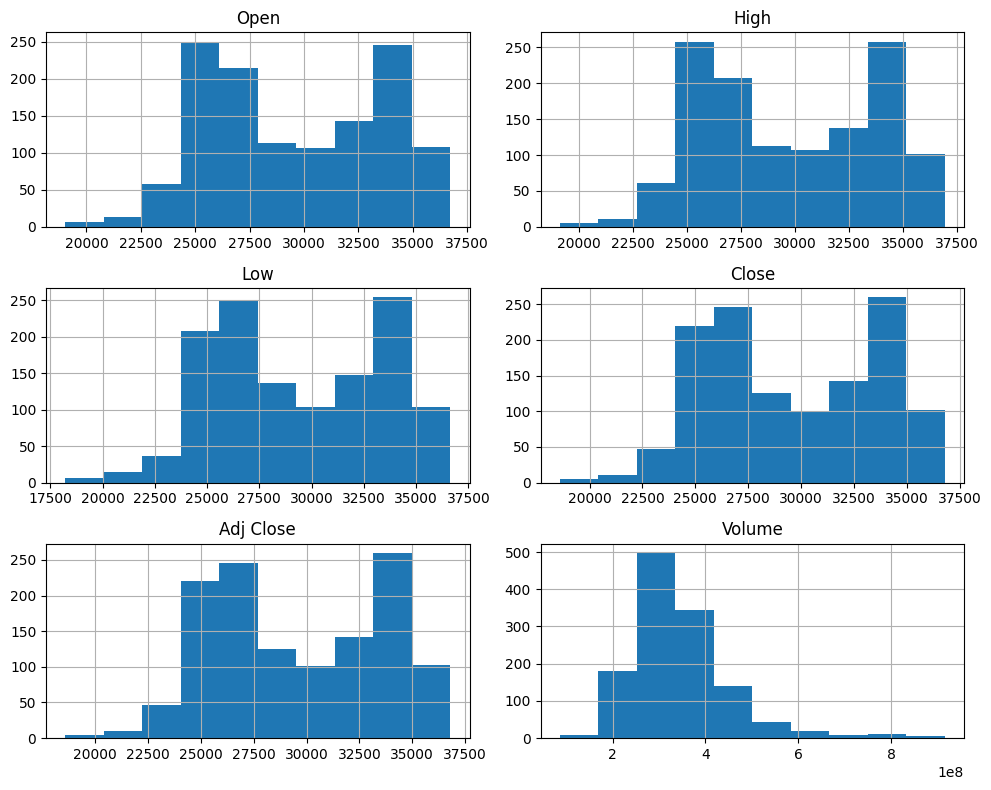

In [14]:
# Applying EDA we
import matplotlib.pyplot as plt
import seaborn as sns
df[num_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

2) Preprocess and clean a sample financial dataset, remove inconsistencies, and prepare it for AI model training.

In [15]:
# Load dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
# Preprocess and clean a sample financial dataset
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,4/28/2023,33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,4/29/2023,33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,4/30/2023,33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,5/1/2023,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,5/2/2023,33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [17]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [20]:
# clean dataset
df.dropna(inplace=True)

In [22]:
# encoding
df = pd.get_dummies(df)

In [23]:
# feature and target
x = df.drop("Volume", axis=1)
y = df["Volume"]
# train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [24]:
# predict
y_pred = model.predict(x_test)

In [25]:
# evaluate
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 52514400.41818758
R2 Score: 0.4244302564968069


**Setion B**

**Descriptive Analysis & Visualization**

1) Create a bar chart to visualize the distribution  of student grades. Generate a pie chart to display the percentage breakdown of different categories.

In [39]:
# Load data
df = pd.read_csv("/content/StPerformData.csv")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

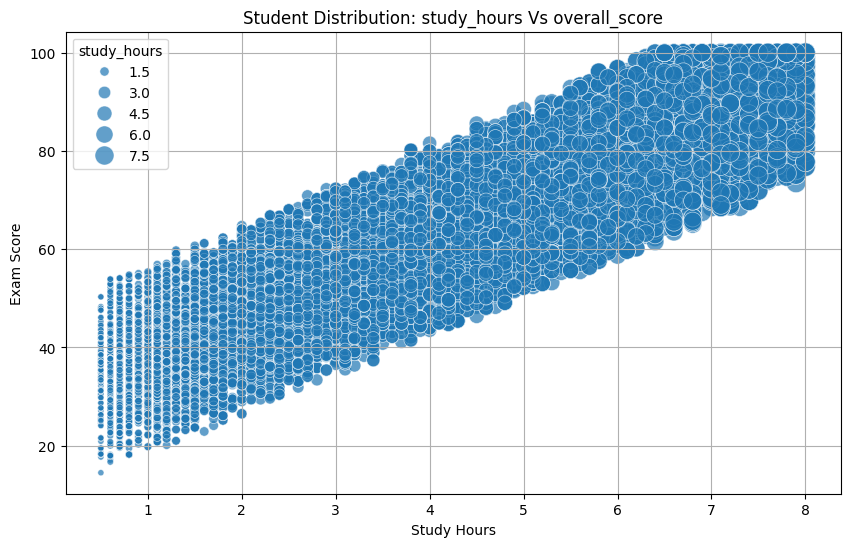

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours', y='overall_score', size='study_hours', sizes=(20,200), alpha=0.7)
plt.title('Student Distribution: study_hours Vs overall_score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

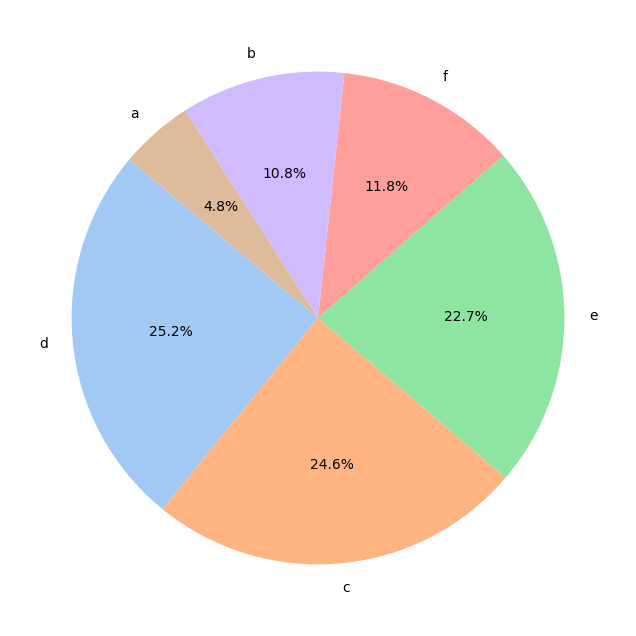

In [42]:
# Percentage Breakdown
plt.figure(figsize=(8,8))
grade_counts = df['final_grade'].value_counts()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.show()

2) Conduct a basic descriptive analysis of your dataset, including measures of central tendency and dispersion. Perform a regression analysis to identify any relationship between variables. create chart to visualize the results of your analysis.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

stats = df[['study_hours', 'overall_score']].describe()
# median ( central tendency), variance (dispersion)
stats.loc['median'] = df[['study_hours', 'overall_score']].median()
stats.loc['var'] = df[['study_hours', 'overall_score']].var()
print("Descriptive Statistics:")
print(stats)

Descriptive Statistics:
         study_hours  overall_score
count   25000.000000   25000.000000
mean        4.253224      64.006172
std         2.167541      18.932025
min         0.500000      14.500000
25%         2.400000      49.000000
50%         4.300000      64.200000
75%         6.100000      79.000000
max         8.000000     100.000000
median      4.300000      64.200000
var         4.698235     358.421553


In [46]:
# variables
x = df['study_hours']
y = df['overall_score']
x = sm.add_constant(x) # intercepting

# fitting model
model = sm.OLS(y, x).fit()

print('\nRegression Results:')
print(f'R-squared: {model.rsquared: .4f}') # it tells how much model is accurate
print(model.params)


Regression Results:
R-squared:  0.8204
const          30.357606
study_hours     7.911308
dtype: float64


Text(0, 0.5, 'Overall Score')

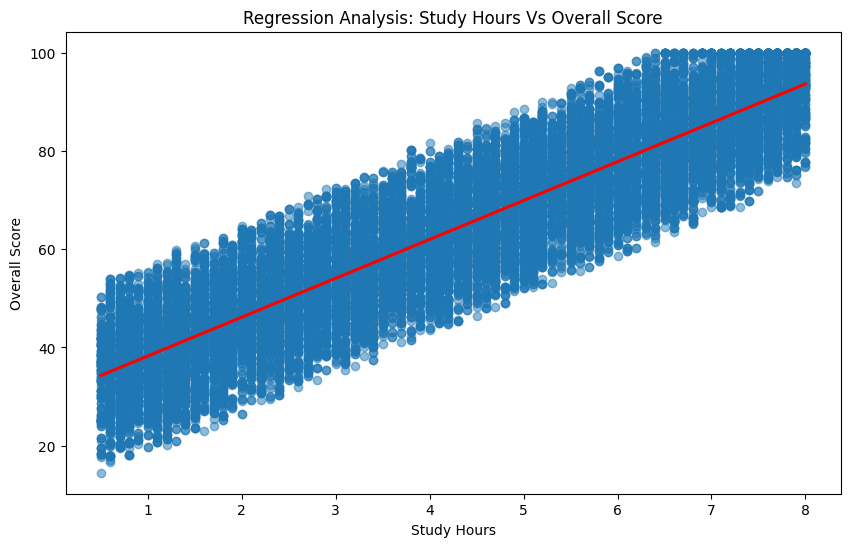

In [50]:
# visualization
plt.figure(figsize=(10,6))
sns.regplot(x='study_hours', y='overall_score', data=df, scatter_kws={'alpha': 0.5},
            line_kws={'color': "red"})
plt.title('Regression Analysis: Study Hours Vs Overall Score')
plt.xlabel('Study Hours')
plt.ylabel('Overall Score')

**Section C**

**Business & Sales Intelligence**

1) Create a project that focuses ondata manipulation and analysis using pandas. Choose a dataset and perform task like data loading, cleaning, and exploration analysis. Showcase the versility of pandas in handling real-world.

In [28]:
# Load data
df = pd.read_csv("/content/StPerformData.csv")
import pandas as pd
import numpy as np

In [29]:
# data checking
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [31]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [32]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


In [33]:
# encoding
df = pd.get_dummies(df)

* Here I also use classification as a model but the requirement was about to manipulate the data thats why I use Linear regression model.

In [35]:
# feature and target
x = df.drop("overall_score", axis=1)
y = df["overall_score"]
# train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [36]:
# predict
y_pred = model.predict(x_test)

In [37]:
# evaluate
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.375203194055161
R2 Score: 0.9756286691765456


**Section D**

**Pattern Discovery & ML**

1) Practicing and forcasting technical analysis via python for any stock selected by the participant.

In [69]:
# Load data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
import matplotlib.pyplot as plt

df = pd.read_csv("/content/yFinData.csv")

In [68]:
#  Converting date
df['Date'] = pd.to_datetime(df['Date'])

In [67]:
#  FEATURES & TARGET
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Close']

In [66]:
#  TRAIN TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [65]:
#  MODEL (DECISION TREE REGRESSOR)
model = DecisionTreeRegressor(max_depth=4)
model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4)

In [70]:
#  PREDICTION
y_pred = model.predict(x_test)

In [71]:
#  EVALUATION
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, y_pred))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 288.7425435307658
Mean Squared Error: 136006.7477832075
R2 Score: 0.9916869003401314


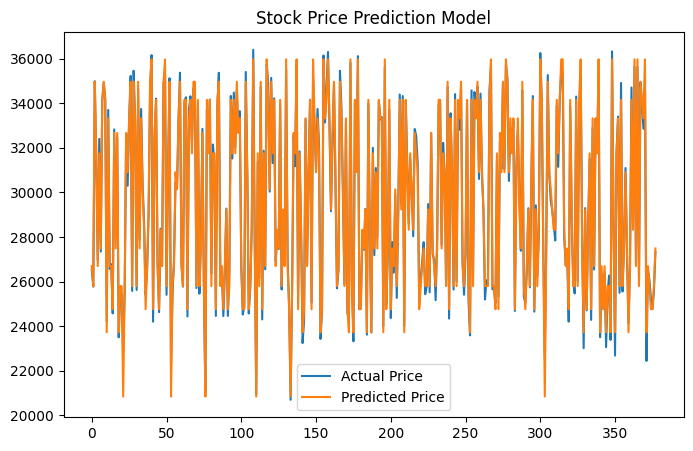

In [72]:
# VISUALIZATION (ACTUAL VS PREDICTED)
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Stock Price Prediction Model")
plt.legend()
plt.show()